In [1]:
import sys
from pathlib import Path
import torch

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent / "train"))

from utils.config import PROJECT_ROOT
from utils.data_split import create_train_val_split
from eGeMAPS_model.extract_feature import extract_egemaps_features_from_csv
from utils.visualization import plot_training_curves
from utils.dataset import create_dataloaders
from eGeMAPS_model.train import train
import numpy as np


/root/autodl-tmp/envs/madress/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_NAME = "Pitt"
data_version = "raw"


In [3]:
# RAW_AUDIO_DIR = PROJECT_ROOT / f"data/denoised/{DATASET_NAME}"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/{data_version}/{DATASET_NAME}"

EGEMAPS_FEATURES_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_egemaps_features"
FEATURE_DIR_NAME = f"{DATASET_NAME}_egemaps_features"
MODEL_OUTPUT_DIR = PROJECT_ROOT / f"models/{DATASET_NAME}_egemaps_multi_seed"


In [4]:
if torch.cuda.is_available():
      device = torch.device('cuda')
      accelerator = 'gpu'
elif torch.backends.mps.is_available():
      device = torch.device('mps')
      accelerator = 'mps'
else:
      device = torch.device('cpu')
      accelerator = 'cpu'
print(f"Using {device}")


Using cuda


## Step 1: Train/Validation Set Split

In [5]:
TRAIN_CSV, VAL_CSV = create_train_val_split(
    raw_audio_dir=RAW_AUDIO_DIR,
    dataset_name=DATASET_NAME,
    feature_dir_name=FEATURE_DIR_NAME,
    xlsr=False,
)


============= Pitt Train(80.0%) and Val(20%) Split Complete! =============
Training set: 440 samples (Control: 193, Dementia: 247)
Validation set: 111 samples (Control: 49, Dementia: 62)


## Step 2: Extract eGeMAPS Features

In [6]:
extract_egemaps_features_from_csv(
    csv_path=TRAIN_CSV,
    raw_audio_dir=RAW_AUDIO_DIR,
)

extract_egemaps_features_from_csv(
    csv_path=VAL_CSV,
    raw_audio_dir=RAW_AUDIO_DIR,
)



============= Extraction eGeMaps features =============
440 Audio Files


Extracting: 100%|██████████| 440/440 [00:00<00:00, 31112.39it/s]

Successfully extracted: 0
Already Exists (Skipped): 440
Total: 440
Errors: 0



============= Extraction eGeMaps features =============
111 Audio Files


Extracting: 100%|██████████| 111/111 [00:00<00:00, 35350.63it/s]

Successfully extracted: 0
Already Exists (Skipped): 111
Total: 111
Errors: 0


## Step 4: Create Data Loaders


In [7]:
train_loader = create_dataloaders(data_csv=TRAIN_CSV)

val_loader = create_dataloaders(data_csv=VAL_CSV)


Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 111 samples
Control: 49, Dementia: 62




## Step 5: Define Training Function and Model


In [8]:
all_results = {
    'seeds': [], 
    'val_accs': [], 
    'val_losses': [], 
    'control_accs': [], 
    'dementia_accs': [], 
    'f1_scores': []
}


### 1st Random Seed = 21

Seed 21:
Val Acc=56.76%, F1=0.7209, Val Loss=0.6879
Control Acc=2.04%, Dementia Acc=100.00%
Early stop at: epoch 13 (best epoch: 3)


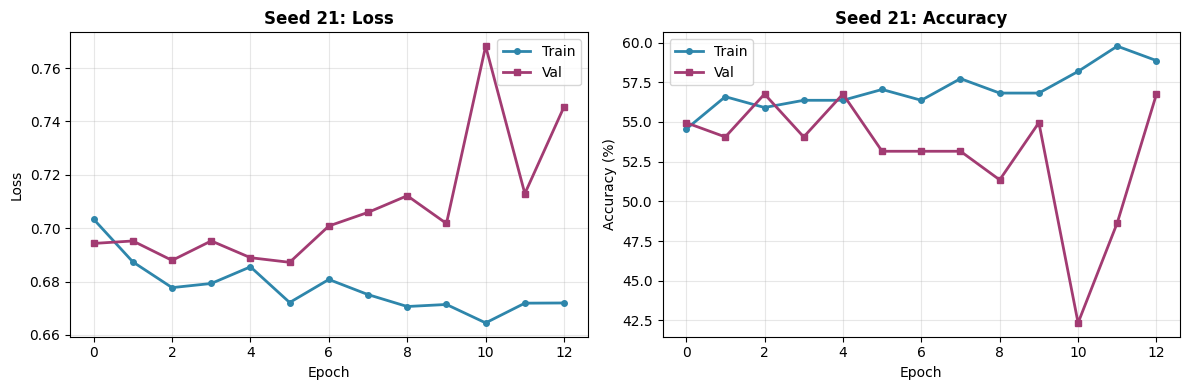

In [9]:
seed, metrics, history = train(seed=21, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)


### 2nd Random Seed = 42

Seed 42:
Val Acc=61.26%, F1=0.6993, Val Loss=0.6911
Control Acc=36.73%, Dementia Acc=80.65%
Early stop at: epoch 17 (best epoch: 7)


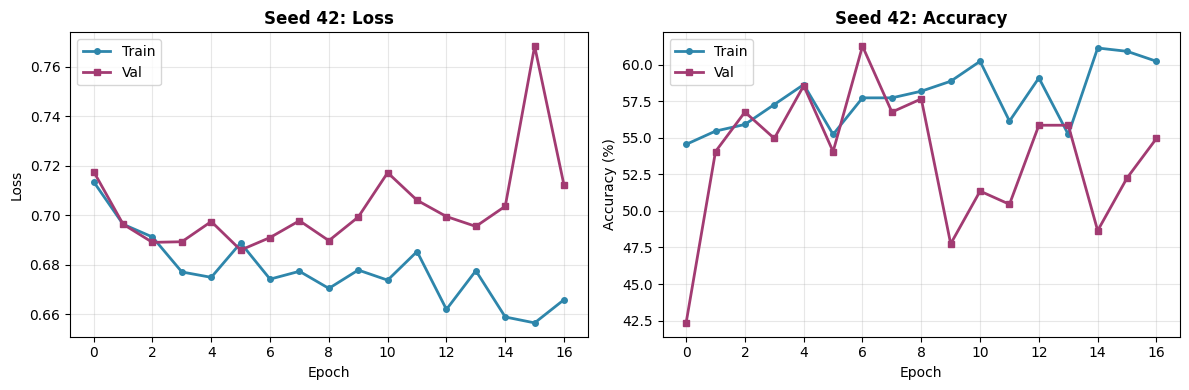

In [10]:
seed, metrics, history = train(seed=42, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)


### 3rd Random Seed = 84

Seed 84:
Val Acc=61.26%, F1=0.7075, Val Loss=0.6806
Control Acc=32.65%, Dementia Acc=83.87%
Early stop at: epoch 12 (best epoch: 2)


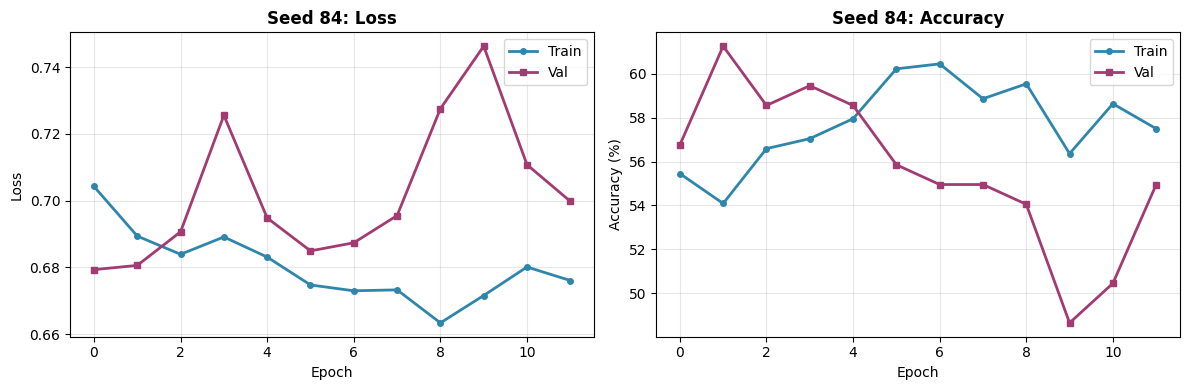

In [11]:
seed, metrics, history = train(seed=84, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)


### 4th Random Seed = 168

Seed 168:
Val Acc=60.36%, F1=0.6393, Val Loss=0.6851
Control Acc=57.14%, Dementia Acc=62.90%
Early stop at: epoch 11 (best epoch: 1)


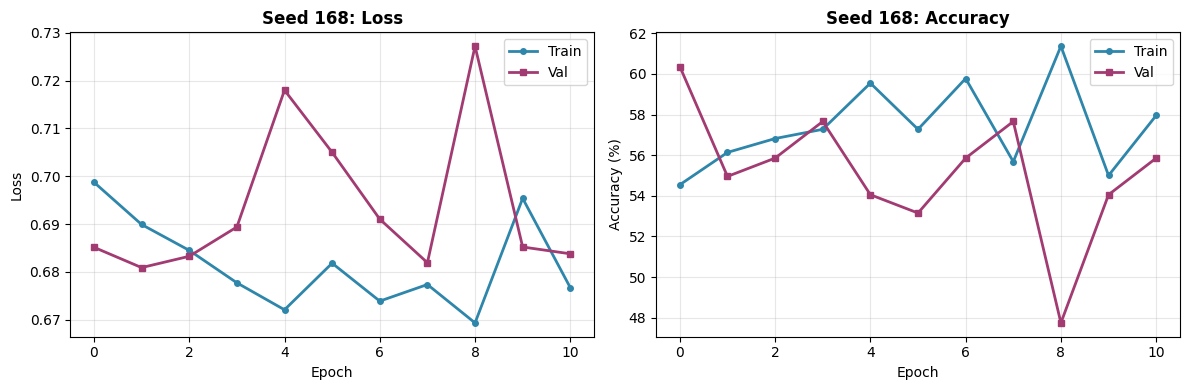

In [12]:
seed, metrics, history = train(seed=168, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)


### 5th Random Seed = 336

Seed 336:
Val Acc=55.86%, F1=0.7168, Val Loss=0.6841
Control Acc=0.00%, Dementia Acc=100.00%
Early stop at: epoch 11 (best epoch: 1)


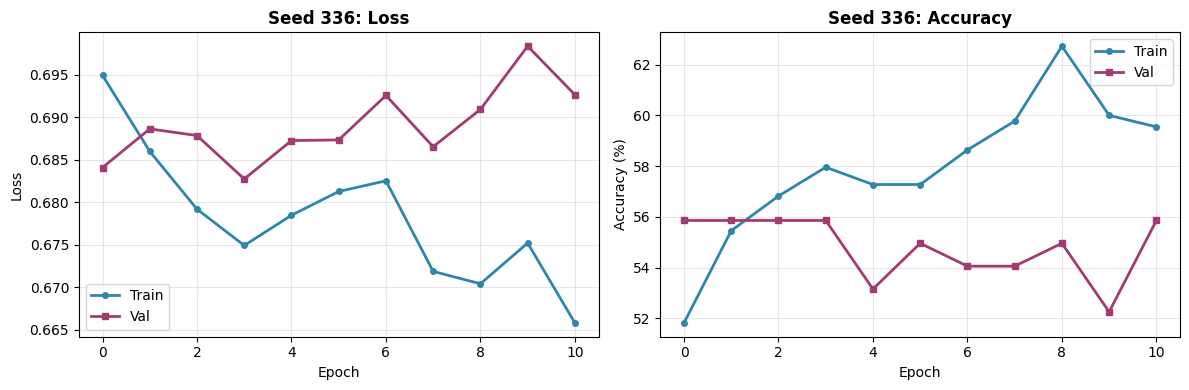

In [13]:
seed, metrics, history = train(seed=336, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)


## Step 6: Summary of Results

In [14]:
seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']
control_accs = [acc*100 for acc in all_results['control_accs']]
dementia_accs = [acc*100 for acc in all_results['dementia_accs']]
f1_scores = all_results['f1_scores']

# Calculate statistics (mean and std)
mean_acc = np.mean(val_accs)
std_acc = np.std(val_accs, ddof=1)

mean_loss = np.mean(val_losses)
std_loss = np.std(val_losses, ddof=1)

mean_control_acc = np.mean(control_accs)
std_control_acc = np.std(control_accs, ddof=1)

mean_dementia_acc = np.mean(dementia_accs)
std_dementia_acc = np.std(dementia_accs, ddof=1)

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores, ddof=1)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f} ± {std_loss:.4f}")
print(f"Mean Control Accuracy: {mean_control_acc:.2f}% ± {std_control_acc:.2f}%")
print(f"Mean Dementia Accuracy: {mean_dementia_acc:.2f}% ± {std_dementia_acc:.2f}%")
print(f"Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}, "
          f"Control Acc={control_accs[i]:.2f}%, Dementia Acc={dementia_accs[i]:.2f}%, F1={f1_scores[i]:.4f}")



Mean Validation Accuracy: 59.10% ± 2.60%
Mean Validation Loss: 0.6858 ± 0.0039
Mean Control Accuracy: 25.71% ± 24.39%
Mean Dementia Accuracy: 85.48% ± 15.47%
Mean F1 Score: 0.6968 ± 0.0332

Detailed Results:
Seed 21: Acc=56.76%, Loss=0.6879, Control Acc=2.04%, Dementia Acc=100.00%, F1=0.7209
Seed 42: Acc=61.26%, Loss=0.6911, Control Acc=36.73%, Dementia Acc=80.65%, F1=0.6993
Seed 84: Acc=61.26%, Loss=0.6806, Control Acc=32.65%, Dementia Acc=83.87%, F1=0.7075
Seed 168: Acc=60.36%, Loss=0.6851, Control Acc=57.14%, Dementia Acc=62.90%, F1=0.6393
Seed 336: Acc=55.86%, Loss=0.6841, Control Acc=0.00%, Dementia Acc=100.00%, F1=0.7168


## Step 7: Test Best Model on Multiple Datasets


In [15]:
# Find the best model: highest accuracy, then lowest loss if tied
max_acc = max(all_results['val_accs'])
max_acc_indices = [i for i, acc in enumerate(all_results['val_accs']) if acc == max_acc]

# If multiple models have the same max accuracy, choose the one with lowest loss
if len(max_acc_indices) > 1:
    print(f"Multiple models with accuracy {max_acc*100:.2f}%, selecting one with lowest loss")
    best_idx = min(max_acc_indices, key=lambda i: all_results['val_losses'][i])
else:
    best_idx = max_acc_indices[0]

# Get best model info
BEST_SEED = all_results['seeds'][best_idx]
BEST_VAL_ACC = all_results['val_accs'][best_idx] * 100
BEST_VAL_LOSS = all_results['val_losses'][best_idx]
BEST_F1 = all_results['f1_scores'][best_idx]
BEST_MODEL_PATH = MODEL_OUTPUT_DIR / f"seed_{BEST_SEED}" / "best.pth"


Multiple models with accuracy 61.26%, selecting one with lowest loss


In [16]:
# Load the best model
from eGeMAPS_model.model import AD_EGE_Model
from eGeMAPS_model.test import test_on_dataset, test_on_dataset_with_val_csv

# Create model with eGeMAPS configuration
test_model = AD_EGE_Model()

# Load checkpoint (state_dict was saved directly)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
test_model.load_state_dict(checkpoint)
test_model = test_model.to(device)
test_model.eval()

# Reference val CSV for cross-dataset testing
REFERENCE_VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-egemaps-val.csv"
print(f"Reference VAL_CSV: {REFERENCE_VAL_CSV}")


Reference VAL_CSV: /root/autodl-tmp/Back_to_Origin/ad_detection/data/processed/Pitt-egemaps-val.csv


In [17]:
all_test_results = {}

test_datasets = [
    ("Lu", "data/raw/Lu"),
    ("Lu-Demucs", "data/denoised/Lu-Demucs"),
    ("Lu-Denoiser", "data/denoised/Lu-Denoiser"),
    ("Lu-FRCRN_SE", "data/denoised/Lu-FRCRN_SE"),
    ("Lu-MossFormer", "data/denoised/Lu-MossFormer"),
    ("Lu-Resemble", "data/denoised/Lu-Resemble"),
]
for name, audio_dir in test_datasets:
    all_test_results[name] = test_on_dataset(
        dataset_name=name, model=test_model, device=device, raw_audio_dir=audio_dir)

# Print summary table
print("\n" + "="*80)
print("SUMMARY OF ALL TEST RESULTS")
print("="*80)
print(f"{'Dataset':<20} {'Accuracy':<12} {'F1 Score':<12} {'Control Acc':<12} {'Dementia Acc':<12}")
print("-"*80)

for dataset_name, results in all_test_results.items():
    print(f"{dataset_name:<20} {results['accuracy']*100:>10.2f}%  {results['f1']:>10.4f}  "
          f"{results['control_acc']*100:>10.2f}%  {results['dementia_acc']*100:>10.2f}%")

print("="*80)


Testing on Lu Dataset


============= Extraction eGeMaps features =============
74 Audio Files


Extracting: 100%|██████████| 74/74 [00:00<00:00, 32934.90it/s]


Successfully extracted: 0
Already Exists (Skipped): 74
Total: 74
Errors: 0
Loading completed: 74 samples
Control: 36, Dementia: 38




Testing on Lu: 100%|██████████| 5/5 [00:00<00:00, 1341.06it/s]


Overall Accuracy: 43.24%, F1 Score: 0.5333
Control Accuracy: 22.22%, Dementia Accuracy: 63.16%

Testing on Lu-Demucs Dataset


============= Extraction eGeMaps features =============
74 Audio Files


...


============= Extraction eGeMaps features =============
74 Audio Files


Extracting: 100%|██████████| 74/74 [00:00<00:00, 36726.84it/s]


Successfully extracted: 0
Already Exists (Skipped): 74
Total: 74
Errors: 0
Loading completed: 74 samples
Control: 36, Dementia: 38




Testing on Lu-Resemble: 100%|██████████| 5/5 [00:00<00:00, 1764.39it/s]

Overall Accuracy: 43.24%, F1 Score: 0.3636
Control Accuracy: 55.56%, Dementia Accuracy: 31.58%

SUMMARY OF ALL TEST RESULTS
Dataset              Accuracy     F1 Score     Control Acc  Dementia Acc
--------------------------------------------------------------------------------
Lu                        43.24%      0.5333       22.22%       63.16%
Lu-Demucs                 40.54%      0.4884       25.00%       55.26%
Lu-Denoiser               55.41%      0.6526       27.78%       81.58%
Lu-FRCRN_SE               52.70%      0.5977       36.11%       68.42%
Lu-MossFormer             58.11%      0.6173       50.00%       65.79%
Lu-Resemble               43.24%      0.3636       55.56%       31.58%


In [18]:
torch.cuda.empty_cache()